連接到google drive

In [ ]:
#@title Google drive
from google.colab import drive

drive.mount('/content/drive')

! pip install -q ultralytics
! pip -q install faiss-cpu

! wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.7 MB/s eta 0:00:00
--2026-03-24 09:15:00--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.250.4.113, 142.250.4.139, 142.250.4.100, ...
Connecting to drive.google.com (drive.google.com)|142.250.4.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-03-24 09:15:01--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.170.132, 2404:6800:4003:c1a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.170.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659

先設定好路徑，可把share的folder在google drive中 按右鍵，add short cut

In [ ]:
import os, glob, pandas as pd
import gradio as gr
from PIL import Image  # 仍可保留，若你有別處用
import os, glob, json, time, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime
import faiss
import torch

# 確保 KAM_Face_pipeline_demo 加到自己的google drive
BASE = "/content/drive/MyDrive/KAM_Face_pipeline_demo" #@param {type:"string"}
WEIGHTS_PATH = os.path.join(BASE, "weights")

import sys
sys.path.append(BASE)

from KAMFace.pipeline import KAMFacePipeline # KAMFace 在 BASE 的文件夾下
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


我們的 pipe

In [ ]:
pipe = KAMFacePipeline(
    yolo_body_detector_path=f'{WEIGHTS_PATH}/best_body.pt',
    yolo_face_detector_path=f'{WEIGHTS_PATH}/best_face.pt',
    pet_face_backbone_path=f'{WEIGHTS_PATH}/best_backbone.pt',
    device='cuda' # <-- cuda 代表使用 gpu
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

In [ ]:
# 文件夾下有 3 張 demo的相片
image_folders = f'{BASE}/demo_cat_images'

os.listdir(image_folders)

['米米豬1.jpg', '紐紐糖3.jpg', '米米豬2.jpg']

讀取相片

Text(0.5, 1.0, '紐紐糖3')

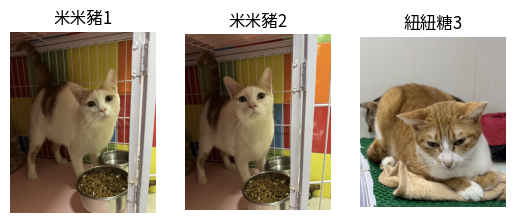

In [ ]:
img_path1 = f'{BASE}/demo_cat_images/米米豬1.jpg'
img_path2 = f'{BASE}/demo_cat_images/米米豬2.jpg'
img_path3 = f'{BASE}/demo_cat_images/紐紐糖3.jpg'

img1 = Image.open(img_path1)
img2 = Image.open(img_path2)
img3 = Image.open(img_path3)

plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.axis('off')
plt.title('米米豬1')

plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.axis('off')
plt.title('米米豬2')

plt.subplot(1, 3, 3)
plt.imshow(img3)
plt.axis('off')
plt.title('紐紐糖3')

In [ ]:
# 可輸入img_path 或 PIL image
# 使用 模型進行 inference
# 返回一個list of dict
result1 = pipe(img_path1)
result2 = pipe(img_path2)
result3 = pipe(img_path3)

type(result1), len(result1), result1[0].keys()

(list,
 1,
 dict_keys(['face_kpts', 'body_bbox', 'face_img', 'body_img', 'img_path', 'feat']))

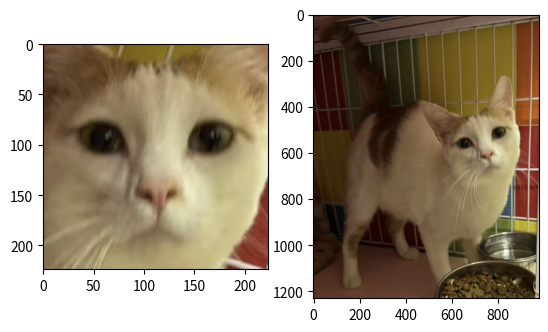

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(result1[0]['face_img'])
plt.subplot(1, 2, 2)
plt.imshow(result1[0]['body_img'])

In [ ]:
# feat 是一個 512的向量
result1[0]['feat'].shape

torch.Size([1, 512])

使用 cosine similarity 比較

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

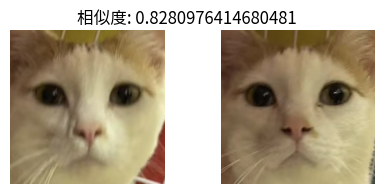

In [ ]:
cos = torch.nn.CosineSimilarity(dim=1)

feat1 = result1[0]['feat']
feat2 = result2[0]['feat']

cos_sim = cos(feat1, feat2).item()

plt.figure(figsize=(5, 2))
plt.suptitle(f'相似度: {cos_sim}')
plt.subplot(1, 2, 1)
plt.imshow(result1[0]['face_img'])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result2[0]['face_img'])
plt.axis('off')


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

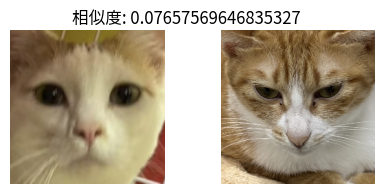

In [ ]:
cos = torch.nn.CosineSimilarity(dim=1)

feat1 = result1[0]['feat']
feat3 = result3[0]['feat']

cos_sim = cos(feat1, feat3).item()

plt.figure(figsize=(5, 2))
plt.suptitle(f'相似度: {cos_sim}')
plt.subplot(1, 2, 1)
plt.imshow(result1[0]['face_img'])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result3[0]['face_img'])
plt.axis('off')
